# A first fit to the real Planck CMB temperature spectrum

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/daanmeerburg/RTG_3186_CMB_Lectures/blob/main/Planck_TT_data_analysis.ipynb)

Click the badge to open and run this notebook directly in Google Colab. No local installation is needed.

This notebook downloads the official **Planck 2018 (PR3) binned TT angular power spectrum**, plots the measured bandpowers, and performs a deliberately simple two-parameter fit:

$$D_\ell^{\rm model}(A,\alpha)=A\,D_{\alpha\ell}^{\rm Planck\ template}.$$

Here $A$ changes the overall fluctuation amplitude and $\alpha$ dilates the multipole axis, mimicking a change in the angular acoustic scale. This is a teaching likelihood using the tabulated one-dimensional errors as independent Gaussian errors. It is **not** the official Planck likelihood and must not be used for research parameter constraints.

## 1. Imports and plotting style
The required packages (`numpy`, `scipy`, and `matplotlib`) are already available in Google Colab.

In [1]:
import io
import urllib.request
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline
from scipy.optimize import least_squares

plt.rcParams.update({
    'figure.figsize': (10, 5.5),
    'font.size': 12,
    'axes.grid': True,
    'grid.alpha': 0.25,
})

## 2. Download the official Planck bandpowers
The file comes from the NASA/IPAC mirror of the Planck Legacy Archive. Its columns are effective multipole $\ell$, measured $D_\ell^{TT}$, lower error, upper error, and the Planck best-fit value. Units are $\mu{\rm K}^2$.

In [2]:
DATA_URL = (
    'https://irsa.ipac.caltech.edu/data/Planck/release_3/'
    'ancillary-data/cosmoparams/COM_PowerSpect_CMB-TT-binned_R3.01.txt'
)

with urllib.request.urlopen(DATA_URL) as response:
    raw_text = response.read().decode('utf-8')

ell, Dl_data, err_minus, err_plus, Dl_template = np.loadtxt(
    io.StringIO(raw_text), unpack=True
)
sigma = 0.5 * (err_minus + err_plus)

print(f'Loaded {ell.size} Planck TT bandpowers.')
print(f'Multipole range: {ell.min():.1f} <= ell <= {ell.max():.1f}')
print('First row:', ell[0], Dl_data[0], sigma[0], Dl_template[0])

Loaded 83 Planck TT bandpowers.
Multipole range: 47.7 <= ell <= 2499.0
First row: 47.711224 1479.33552 50.7654876 1461.11304


## 3. Plot the real data
Recall that $D_\ell=\ell(\ell+1)C_\ell/(2\pi)$. The oscillations are the acoustic peaks derived in the lectures.

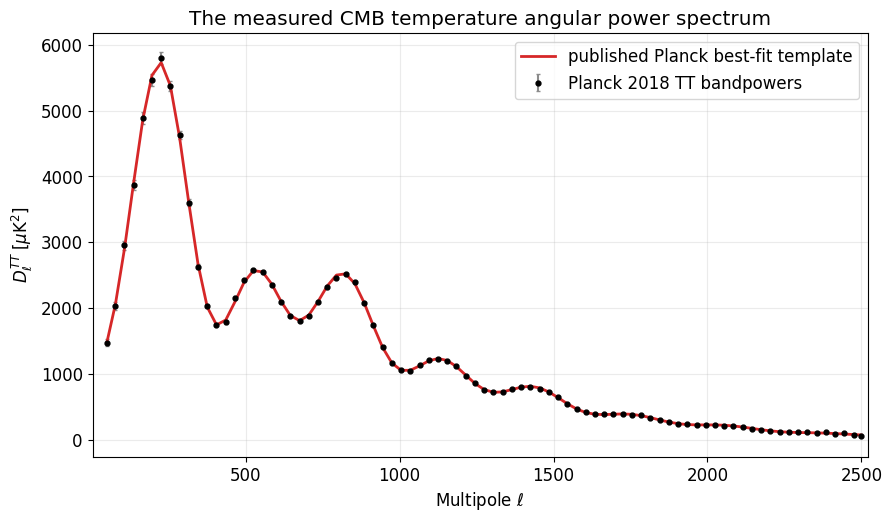

In [3]:
fig, ax = plt.subplots()
ax.errorbar(ell, Dl_data, yerr=[err_minus, err_plus], fmt='o', ms=3.5,
            color='black', ecolor='0.55', capsize=1.5, label='Planck 2018 TT bandpowers')
ax.plot(ell, Dl_template, color='tab:red', lw=2, label='published Planck best-fit template')
ax.set(xlabel=r'Multipole $\ell$', ylabel=r'$D_\ell^{TT}\;[\mu{\rm K}^2]$',
       title='The measured CMB temperature angular power spectrum')
ax.set_xlim(2, 2520)
ax.legend()
plt.show()

## 4. Define a two-parameter teaching model
We spline the published best-fit spectrum and transform it as

$$D_\ell(A,\alpha)=A D_{\alpha\ell}^{\rm template}.
$$

- $A$ represents an overall amplitude change (loosely related to $A_s e^{-2\tau_{\rm reio}}$).
- $\alpha$ shifts every feature horizontally (loosely related to changing $\theta_s$).

We restrict the fit to $50<\ell<2000$ so interpolation remains safe under the allowed dilation and so the simple Gaussian approximation is less poor.

In [4]:
template = CubicSpline(ell, Dl_template)
use = (ell > 50) & (ell < 2000)

def model(parameters, ell_values=ell[use]):
    amplitude, alpha = parameters
    return amplitude * template(alpha * ell_values)

def normalized_residuals(parameters):
    return (Dl_data[use] - model(parameters)) / sigma[use]

initial_guess = np.array([1.0, 1.0])
fit = least_squares(
    normalized_residuals, initial_guess,
    bounds=([0.8, 0.98], [1.2, 1.02])
)
A_fit, alpha_fit = fit.x
chi2 = np.sum(normalized_residuals(fit.x)**2)
dof = use.sum() - fit.x.size

# Curvature approximation to the parameter covariance.
cov = np.linalg.inv(fit.jac.T @ fit.jac)
parameter_errors = np.sqrt(np.diag(cov))

print(f'A     = {A_fit:.5f} +/- {parameter_errors[0]:.5f}')
print(f'alpha = {alpha_fit:.6f} +/- {parameter_errors[1]:.6f}')
print(f'chi2 / dof = {chi2:.1f} / {dof} = {chi2/dof:.2f}')

A     = 1.00011 +/- 0.00137
alpha = 1.000026 +/- 0.000382
chi2 / dof = 58.7 / 63 = 0.93


## 5. Show the fit and its residuals
Residuals make small mismatches much easier to see than the spectrum alone.

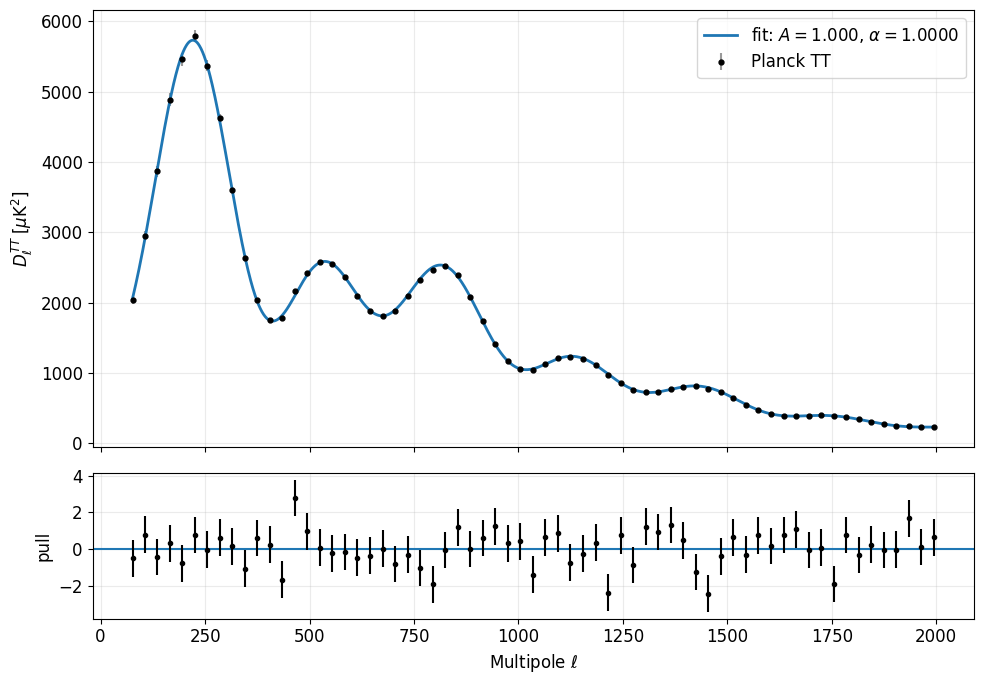

In [5]:
ell_smooth = np.linspace(ell[use].min(), ell[use].max(), 1500)
Dl_fit_smooth = A_fit * template(alpha_fit * ell_smooth)
Dl_fit_at_data = model(fit.x)

fig, (ax, axr) = plt.subplots(2, 1, figsize=(10, 7), sharex=True,
                                gridspec_kw={'height_ratios': [3, 1]})
ax.errorbar(ell[use], Dl_data[use], yerr=sigma[use], fmt='o', ms=3.5,
            color='black', ecolor='0.6', label='Planck TT')
ax.plot(ell_smooth, Dl_fit_smooth, color='tab:blue', lw=2,
        label=fr'fit: $A={A_fit:.3f}$, $\alpha={alpha_fit:.4f}$')
ax.set_ylabel(r'$D_\ell^{TT}\;[\mu{\rm K}^2]$')
ax.legend()

pull = (Dl_data[use] - Dl_fit_at_data) / sigma[use]
axr.axhline(0, color='tab:blue', lw=1.5)
axr.errorbar(ell[use], pull, yerr=np.ones_like(pull), fmt='o', ms=3, color='black')
axr.set(xlabel=r'Multipole $\ell$', ylabel='pull')
plt.tight_layout()
plt.show()

## 6. Visualize the likelihood surface
The contours show whether amplitude and horizontal scale are degenerate in this simplified fit. For two parameters, $\Delta\chi^2=2.30$ and $6.18$ approximately enclose 68% and 95% probability for a Gaussian likelihood.

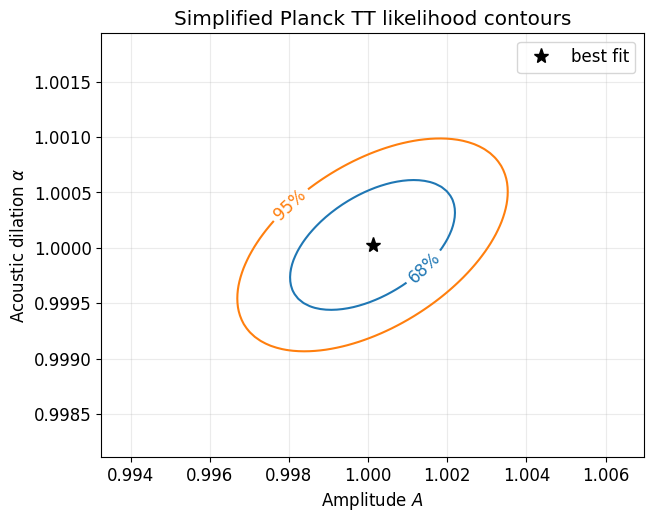

In [6]:
A_grid = np.linspace(A_fit - 5*parameter_errors[0], A_fit + 5*parameter_errors[0], 100)
alpha_grid = np.linspace(alpha_fit - 5*parameter_errors[1],
                         alpha_fit + 5*parameter_errors[1], 100)
chi2_grid = np.empty((alpha_grid.size, A_grid.size))
for i, alpha in enumerate(alpha_grid):
    for j, amplitude in enumerate(A_grid):
        chi2_grid[i, j] = np.sum(normalized_residuals([amplitude, alpha])**2)

fig, ax = plt.subplots(figsize=(7, 5.5))
contours = ax.contour(A_grid, alpha_grid, chi2_grid - chi2,
                      levels=[2.30, 6.18], colors=['tab:blue', 'tab:orange'])
ax.clabel(contours, fmt={2.30: '68%', 6.18: '95%'})
ax.plot(A_fit, alpha_fit, 'k*', ms=11, label='best fit')
ax.set(xlabel=r'Amplitude $A$', ylabel=r'Acoustic dilation $\alpha$',
       title='Simplified Planck TT likelihood contours')
ax.legend()
plt.show()

## 7. Interpretation and limitations

1. Is $A=1$ consistent with the data? Is $\alpha=1$? Why should they be, given how the template was obtained?
2. Change the fitting range. Which result is more stable, amplitude or scale?
3. Set $\alpha=1$ and fit only $A$. How does its uncertainty change?
4. Why is the reported $\chi^2$ not an official goodness-of-fit statistic?

Important limitations: the public bandpowers have correlated uncertainties; the official low-$\ell$ likelihood is non-Gaussian; foreground and calibration nuisance parameters have already entered the published spectrum; and $(A,\alpha)$ are phenomenological rather than fundamental cosmological parameters. A research analysis predicts TT/TE/EE spectra with CAMB or CLASS and evaluates the official likelihood with its covariance and nuisance model.

## Sources

- [Planck Legacy Archive description of the CMB spectra](https://wiki.cosmos.esa.int/planck-legacy-archive/index.php/CMB_spectrum_%26_Likelihood_Code)
- [Official PR3 ancillary-data directory](https://irsa.ipac.caltech.edu/data/Planck/release_3/ancillary-data/cosmoparams/)
- Planck Collaboration, *Planck 2018 results. V. CMB power spectra and likelihoods*, A&A 641, A5 (2020).